# Лабораторная работа 1.1 - Извлечение признаков из текста



## Импорты и загрузка данных

In [ ]:
!pip install pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 49.4 MB/s eta 0:00:00


In [ ]:
import nltk
import pandas as pd
import pymorphy3
import re
import string
from nltk.corpus import stopwords

# Загрузка стоп-слов
nltk.download('stopwords')
stopwords_ru = set(stopwords.words('russian'))

# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()
token_pattern = re.compile(r'\w+', re.UNICODE)

# Загрузка корпусов
path_n = '/content/negative.csv'
path_p = '/content/positive.csv'

# Читаем CSV без указания имен столбцов
df_n = pd.read_csv(path_n, sep=';', header=None)
df_p = pd.read_csv(path_p, sep=';', header=None)

# Объединение позитивного и негативного корпусов
df = pd.concat([df_n, df_p], axis=0, ignore_index=True)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


## Предобработка текста

In [ ]:
# Удаляем "хорошо" и "плохо" из стоп-слов
words_to_keep = {'хорошо', 'плохо'}
stopwords_ru = stopwords_ru - words_to_keep

#  регулярки
URL_PATTERN = re.compile(r'http\S+|www\S+|https\S+')
MENTION_PATTERN = re.compile(r'@\w+')
PUNCT_PATTERN = re.compile(r'[^\w\s]')
DIGIT_PATTERN = re.compile(r'\d+')
SPACE_PATTERN = re.compile(r'\s+')
BAD_WORD_PATTERN = re.compile(r'[бвгджзйклмнпрстфхцчшщ]{5,}|[аеёиоуыэюя]{5,}')

# Список
garbage_words = {
    'аа', 'ааа', 'уу', 'ууу', 'оо', 'ооо', 'мм', 'ммм', 'ыы', 'ыыы',
    'ахах', 'хаха', 'хихи', 'хд', 'лол', 'кек', 'азаз', 'ахахах', 'хахаха',
    'блин', 'капец', 'пипец', 'жесть', 'ваще', 'типа', 'крч',
    'бля', 'блять', 'сука', 'ппц', 'пздц',
    'хнык', 'фуу', 'буэ', 'ой', 'эй', 'ау', 'упс'
}

# Значимые части речи
VALID_POS = {'NOUN', 'ADJF', 'ADJS', 'VERB', 'INFN', 'ADVB', 'PRTS', 'PRTF', 'COMP'}

def clean_text(text):
    """Очищает текст, удаляя все стоп-слова кроме хорошо/плохо"""
    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Базовая очистка
    text = text.lower()
    text = URL_PATTERN.sub('', text)
    text = MENTION_PATTERN.sub('', text)
    text = PUNCT_PATTERN.sub(' ', text)
    text = DIGIT_PATTERN.sub('', text)
    text = SPACE_PATTERN.sub(' ', text).strip()

    words = text.split()
    cleaned = []

    for word in words:
        # Слишком короткие
        if len(word) <= 2:
            continue

        if word in garbage_words:
            continue

        #  последовательности
        if BAD_WORD_PATTERN.search(word):
            continue

        # Лемматизация
        try:
            parsed = morph.parse(word)[0]
            pos = parsed.tag.POS
            lemma = parsed.normal_form

            # Проверяем стоп-слова
            if lemma in stopwords_ru:
                continue

            # Оставляем только значимые части речи
            if pos in VALID_POS:
                cleaned.append(lemma)

        except:
            # Если лемматизация не удалась, но слово длинное - оставляем
            if len(word) > 3:
                cleaned.append(word)

    return ' '.join(cleaned)

df['original_text'] = df[3]

df[3] = df[3].apply(clean_text)
df[3] = df[3].fillna('').astype(str)

In [ ]:
df[[3]].head(19)

,3
0,работа полный пиддес каждый закрытие месяц сви...
1,коллега сидеть рубиться долбать винд мочь
2,говорить обещаной год ждать
3,желать хороший полёт удачный посадка очень сил...
4,обновить леший работать простоплеер
5,котёнок вчера носик разбить плакать расстраива...
6,заслать затихариться прямо физически страдать ...
7,вообще болеть выздоравливать
8,микрофраза учиться срать кирпич режим нона
9,хотеть помириться гордый сделать


## Тональные признаки (LinisCrowd 2015)

In [ ]:
import pandas as pd
import numpy as np

# Загрузка словаря
df_dict = pd.read_csv('/content/words_all_full_rating.csv', sep=';', encoding='cp1251')
sentiment_dict = {}
for _, row in df_dict.iterrows():
    word = str(row.iloc[0]).strip('"')
    score = float(str(row.iloc[1]).replace('"', '').replace(',', '.'))
    sentiment_dict[word] = score

# Извлечение признаков
features = []
for text in df[3]:
    tokens = str(text).lower().split()
    sents = [sentiment_dict[t] for t in tokens if t in sentiment_dict]

    if not sents:
        sents = [0]

    features.append([
        np.mean(sents),
        np.max(sents),
        np.min(sents),
        np.sum(sents),
        sum(1 for x in sents if x > 0),
        sum(1 for x in sents if x < 0)
    ])

#  признаки
feat_df = pd.DataFrame(features, columns=['avg', 'max', 'min', 'sum', 'pos', 'neg'])
df[['avg', 'max', 'min', 'sum', 'pos', 'neg']] = feat_df

In [ ]:
df = df.rename(columns={3: 'text'})

In [ ]:
df = df.drop(columns=[0,1,2,5,6,7,8,9,10,11,'original_text']).rename(columns={4:'label'})

In [ ]:
df["label"] = df["label"].map({-1: 0, 1: 1})

In [ ]:
df

,text,label,avg,max,min,sum,pos,neg
0,работа полный пиддес каждый закрытие месяц сви...,0,0.129630,0.222222,0.000000,0.388889,2,0
1,коллега сидеть рубиться долбать винд мочь,0,-0.200000,-0.200000,-0.200000,-0.200000,0,1
2,говорить обещаной год ждать,0,0.000000,0.000000,0.000000,0.000000,0,0
3,желать хороший полёт удачный посадка очень сил...,0,0.740741,1.222222,0.000000,2.222222,2,0
4,обновить леший работать простоплеер,0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...
226829,спасть родительский дом свой кровать проснутьс...,1,0.000000,0.000000,0.000000,0.000000,0,0
226830,немного решить сократить путь лежать мягкий кр...,1,0.092593,0.500000,-0.222222,0.277778,1,1
226831,происходить эфир звучать любимый песня,1,0.666667,1.333333,0.000000,1.333333,1,0
226832,любимый подарить звезда имя звезда переводитьс...,1,0.833333,1.333333,0.000000,3.333333,3,0


In [ ]:
df.to_csv('dataset_with_features.csv', index=False, header=False)

## Морфологические признаки

In [ ]:
import pymorphy3
from collections import Counter

# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

# Функция для определения части речи
def get_pos(word):
    try:
        parse = morph.parse(word)[0]
        return parse.tag.POS if parse.tag.POS else 'UNKN'
    except:
        return 'UNKN'

# Список частей речи
pos_list = ['NOUN', 'ADJF', 'ADJS', 'VERB', 'INFN', 'PRTF', 'PRTS', 'GRND',
            'NUMR', 'ADVB', 'NPRO', 'PRED', 'PREP', 'CONJ', 'PRCL', 'INTJ']

# Извлечение признаков
pos_features = []
for text in df['text']:
    tokens = str(text).lower().split()
    if not tokens:
        pos_features.append([0] * len(pos_list))
        continue

    # Определение частей речи для всех токенов
    pos_tags = [get_pos(token) for token in tokens]

    # Подсчет частот
    pos_counts = Counter(pos_tags)
    total = len(tokens)

    # Относительные частоты
    rel_freqs = [pos_counts.get(pos, 0) / total for pos in pos_list]
    pos_features.append(rel_freqs)

# Создание DataFrame с признаками
pos_df = pd.DataFrame(pos_features, columns=[f'pos_{p.lower()}' for p in pos_list])

df = pd.concat([df, pos_df], axis=1)

In [ ]:
df

,text,label,avg,max,min,sum,pos,neg,pos_noun,pos_adjf,...,pos_prts,pos_grnd,pos_numr,pos_advb,pos_npro,pos_pred,pos_prep,pos_conj,pos_prcl,pos_intj
0,работа полный пиддес каждый закрытие месяц сви...,0,0.129630,0.222222,0.000000,0.388889,2,0,0.571429,0.285714,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,коллега сидеть рубиться долбать винд мочь,0,-0.200000,-0.200000,-0.200000,-0.200000,0,1,0.500000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,говорить обещаной год ждать,0,0.000000,0.000000,0.000000,0.000000,0,0,0.250000,0.250000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,желать хороший полёт удачный посадка очень сил...,0,0.740741,1.222222,0.000000,2.222222,2,0,0.250000,0.250000,...,0.0,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,0.0
4,обновить леший работать простоплеер,0,0.000000,0.000000,0.000000,0.000000,0,0,0.500000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226829,спасть родительский дом свой кровать проснутьс...,1,0.000000,0.000000,0.000000,0.000000,0,0,0.500000,0.250000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
226830,немного решить сократить путь лежать мягкий кр...,1,0.092593,0.500000,-0.222222,0.277778,1,1,0.363636,0.090909,...,0.0,0.0,0.0,0.090909,0.0,0.0,0.0,0.0,0.0,0.0
226831,происходить эфир звучать любимый песня,1,0.666667,1.333333,0.000000,1.333333,1,0,0.400000,0.200000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
226832,любимый подарить звезда имя звезда переводитьс...,1,0.833333,1.333333,0.000000,3.333333,3,0,0.571429,0.142857,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.to_csv('dataset_with_morph_features.csv', index=False)

## TF-IDF признаки

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Создание TF-IDF векторайзера с ограничением до 1000 признаков
tfidf = TfidfVectorizer(max_features=1000)

# Преобразование текстов в TF-IDF матрицу
X_tfidf = tfidf.fit_transform(df['text'])

# Создание DataFrame с TF-IDF признаками
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=[f'tfidf_{i}' for i in range(X_tfidf.shape[1])]
)

# Объединение с исходным DataFrame
df = pd.concat([df, tfidf_df], axis=1)

In [ ]:
df

,text,label,avg,max,min,sum,pos,neg,pos_noun,pos_adjf,...,tfidf_990,tfidf_991,tfidf_992,tfidf_993,tfidf_994,tfidf_995,tfidf_996,tfidf_997,tfidf_998,tfidf_999
0,работа полный пиддес каждый закрытие месяц сви...,0,0.129630,0.222222,0.000000,0.388889,2,0,0.571429,0.285714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,коллега сидеть рубиться долбать винд мочь,0,-0.200000,-0.200000,-0.200000,-0.200000,0,1,0.500000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,говорить обещаной год ждать,0,0.000000,0.000000,0.000000,0.000000,0,0,0.250000,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,желать хороший полёт удачный посадка очень сил...,0,0.740741,1.222222,0.000000,2.222222,2,0,0.250000,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,обновить леший работать простоплеер,0,0.000000,0.000000,0.000000,0.000000,0,0,0.500000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226829,спасть родительский дом свой кровать проснутьс...,1,0.000000,0.000000,0.000000,0.000000,0,0,0.500000,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226830,немного решить сократить путь лежать мягкий кр...,1,0.092593,0.500000,-0.222222,0.277778,1,1,0.363636,0.090909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226831,происходить эфир звучать любимый песня,1,0.666667,1.333333,0.000000,1.333333,1,0,0.400000,0.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226832,любимый подарить звезда имя звезда переводитьс...,1,0.833333,1.333333,0.000000,3.333333,3,0,0.571429,0.142857,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.to_csv('dataset_with_tfidf.csv', index=False)

## Классификатор на полученных признаках

ОБУЧЕНИЕ НА ТОНАЛЬНЫХ ПРИЗНАКАХ

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Загрузка
df = df.sample(n=10000, random_state=42)

# Тональные признаки
tonal_features = ['avg', 'max', 'min', 'sum', 'pos', 'neg']
X_tonal = df[tonal_features]
y = df['label']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_tonal, y, test_size=0.2, random_state=42, stratify=y
)

# Обучение
lr_tonal = LogisticRegression(max_iter=1000, random_state=42)
lr_tonal.fit(X_train, y_train)

# Предсказание
y_pred_tonal = lr_tonal.predict(X_test)

# Результаты
print(f"Accuracy: {accuracy_score(y_test, y_pred_tonal):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tonal, target_names=['class_0', 'class_1']))

Accuracy: 0.5540

Classification Report:
              precision    recall  f1-score   support

     class_0       0.54      0.75      0.63       995
     class_1       0.59      0.36      0.45      1005

    accuracy                           0.55      2000
   macro avg       0.57      0.55      0.54      2000
weighted avg       0.57      0.55      0.54      2000



КЛАССИФИКАЦИЯ НА МОРФОЛОГИЧЕСКИХ ПРИЗНАКАХ

In [ ]:
# Загрузка
df = pd.read_csv('dataset_with_tfidf.csv').fillna(0)
df = df.sample(n=10000, random_state=42)

# Морфологические признаки
morph_features = [col for col in df.columns if col.startswith('pos_')]
X_morph = df[morph_features]
y = df['label']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_morph, y, test_size=0.2, random_state=42, stratify=y
)

# Обучение
lr_morph = LogisticRegression(max_iter=1000, random_state=42)
lr_morph.fit(X_train, y_train)

# Предсказание
y_pred_morph = lr_morph.predict(X_test)

# Результаты
print(f"Accuracy: {accuracy_score(y_test, y_pred_morph):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_morph, target_names=['class_0', 'class_1']))

Accuracy: 0.5570

Classification Report:
              precision    recall  f1-score   support

     class_0       0.56      0.50      0.53       995
     class_1       0.55      0.62      0.58      1005

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.56      0.56      0.56      2000



КЛАССИФИКАЦИЯ НА TF-IDF ПРИЗНАКАХ

In [ ]:
# Загрузка
df = pd.read_csv('dataset_with_tfidf.csv').fillna(0)
df = df.sample(n=10000, random_state=42)

# TF-IDF признаки
tfidf_features = [col for col in df.columns if col.startswith('tfidf_')]
X_tfidf = df[tfidf_features]
y = df['label']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Обучение
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train, y_train)

# Предсказание
y_pred_tfidf = lr_tfidf.predict(X_test)

# Результаты
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['class_0', 'class_1']))

Accuracy: 0.6435

Classification Report:
              precision    recall  f1-score   support

     class_0       0.66      0.58      0.62       995
     class_1       0.63      0.71      0.67      1005

    accuracy                           0.64      2000
   macro avg       0.65      0.64      0.64      2000
weighted avg       0.65      0.64      0.64      2000



# Лабораторная работа 1.2 - Извлечение признаков из текста

In [ ]:
!pip install pandas numpy scikit-learn gensim ufal.udpipe wget

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 34.0 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=64fbbda6627d2fe624dc188425d7bc9eb6aae7f3188100fedcdc15bc545e32e1
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
# все тексты в файл
df['text'].to_csv('all_texts.txt', index=False, header=False, encoding='utf-8')

In [ ]:
!cat all_texts.txt | python3 rus_preprocessing_udpipe.py > processed_texts.txt

/content/rus_preprocessing_udpipe.py:128: SyntaxWarning: invalid escape sequence '\|'
  '\t\n\r абвгдеёзжийклмнопрстуфхцчшщьыъэюяАБВГДЕЁЗЖИЙКЛМНОПРСТУФХЦЧШЩЬЫЪЭЮЯ,.[]{}()=+-−*&^%$#@!?~;:0123456789§/\|"abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ '
/content/rus_preprocessing_udpipe.py:184: SyntaxWarning: invalid escape sequence '\s'
  if "SpacesAfter=\\n" in misc or "SpacesAfter=\s\\n" in misc:
UDPipe model not found. Downloading...

Loading the model...
Processing input...


In [ ]:
import pandas as pd
import numpy as np

df = df.sample(n=10000, random_state=42)

#  обработанные токены
with open('processed_texts.txt', 'r', encoding='utf-8') as f:
    processed_lines = [line.strip().split() for line in f]

# Добавляем в датафрейм
df['processed_tokens'] = processed_lines

In [ ]:
df[['text', 'processed_tokens']].head()

,text,processed_tokens
45293,самый любимый доктор милый,"[оставаться_VERB, самый_ADJ, нужный_ADJ, самый..."
120615,каток хорошо особенно уметь кататься конёк уметь,"[приятный_ADJ, чувство_NOUN, знать_VERB, дарит..."
153046,надада ном бэлэглэхо хүсэлтэя байвал бэлэглээр...,"[день_NOUN, начинаться_VERB, лень_ADV, вообще_..."
40476,никакой треугольник кон гидроксид калий,"[ксюш_NOUN, поход_NOUN, вплотную_ADV, суп_ADJ,..."
58850,последний время часто стать говорить красивый ...,"[день_NOUN, рождение_NOUN, творческий_ADJ, усп..."


Скачиваем tayga-func_upos_skipgram_300_5_2019

In [ ]:
from gensim.models import Word2Vec, KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Функция для усреднения векторов
def get_avg_vector(tokens, model, size):
    vectors = [model[token] for token in tokens if token in model]
    if not vectors:
        return np.zeros(size)
    return np.mean(vectors, axis=0)

## Word2Vec самостоятельно обученный

In [ ]:
w2v_self = Word2Vec(sentences=df['processed_tokens'], vector_size=100, window=5, min_count=1)
df['w2v_self'] = df['processed_tokens'].apply(lambda x: get_avg_vector(x, w2v_self.wv, 100))

In [ ]:
vector = w2v_self.wv['день_NOUN']
print(f"Размерность вектора: {len(vector)}")
print(f"Первые 10 координат: {vector[:10]}")

Размерность вектора: 100
Первые 10 координат: [-0.09629997  0.1686917   0.04720092 -0.01656667  0.05667319 -0.25740677
  0.08863539  0.3741649  -0.07985266 -0.12848856]


## Предобученные Word2vec-признаки

In [ ]:
model_w2v = KeyedVectors.load_word2vec_format('/content/model.bin', binary=True)
df['w2v_pre'] = df['processed_tokens'].apply(lambda x: get_avg_vector(x, model_w2v, 300))

## FastText самостоятельно обученный

In [ ]:
from gensim.models import FastText
ft_self = FastText(sentences=df['processed_tokens'], vector_size=100, window=5, min_count=1)
df['ft_self'] = df['processed_tokens'].apply(lambda x: get_avg_vector(x, ft_self.wv, 100))

## Предобученные Fasttext -признаки

In [ ]:
model_ft = KeyedVectors.load_word2vec_format('/content/model.bin', binary=True)
df['ft_pre'] = df['processed_tokens'].apply(lambda x: get_avg_vector(x, model_ft, 300))

Классификация для каждого набора признаков

In [ ]:
feature_sets = {
    'Word2Vec_Self': 'w2v_self',
    'Word2Vec_Pre': 'w2v_pre',
    'FastText_Self': 'ft_self',
    'FastText_Pre': 'ft_pre'
}

for name, col in feature_sets.items():

    X = np.vstack(df[col].values)
    y = df['label'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Accuracy: 0.5025
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       995
           1       0.50      1.00      0.67      1005

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.34      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5050
              precision    recall  f1-score   support

           0       0.50      0.48      0.49       995
           1       0.51      0.53      0.52      1005

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.51      0.50      2000

Accuracy: 0.4880
              precision    recall  f1-score   support

           0       0.48      0.37      0.42       995
           1       0.49      0.60      0.54      1005

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.48      2000
weighted avg       0.49      0.49      0.48      2000

Accuracy: 0.5050
              precision    recall  f1-score   support

           0       0.50      0.48      0.49       995
           1       0.51      0.53      0.52      1005

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50

## Сравнение всех классификаторов

  Тональные  Accuracy: 0.5710
  Морфологические  Accuracy: 0.5425
  TF-IDF  Accuracy: 0.6355
  Word2Vec (самост.)  Accuracy: 0.5025
  Word2Vec (предоб.)  Accuracy: 0.5050
  FastText (самост.)  Accuracy: 0.4880
  FastText (предоб.)  Accuracy: 0.5050
TF-IDF                   : 0.6355
Тональные                : 0.5710
Морфологические          : 0.5425
Word2Vec (предоб.)       : 0.5050
FastText (предоб.)       : 0.5050
Word2Vec (самост.)       : 0.5025
FastText (самост.)       : 0.4880


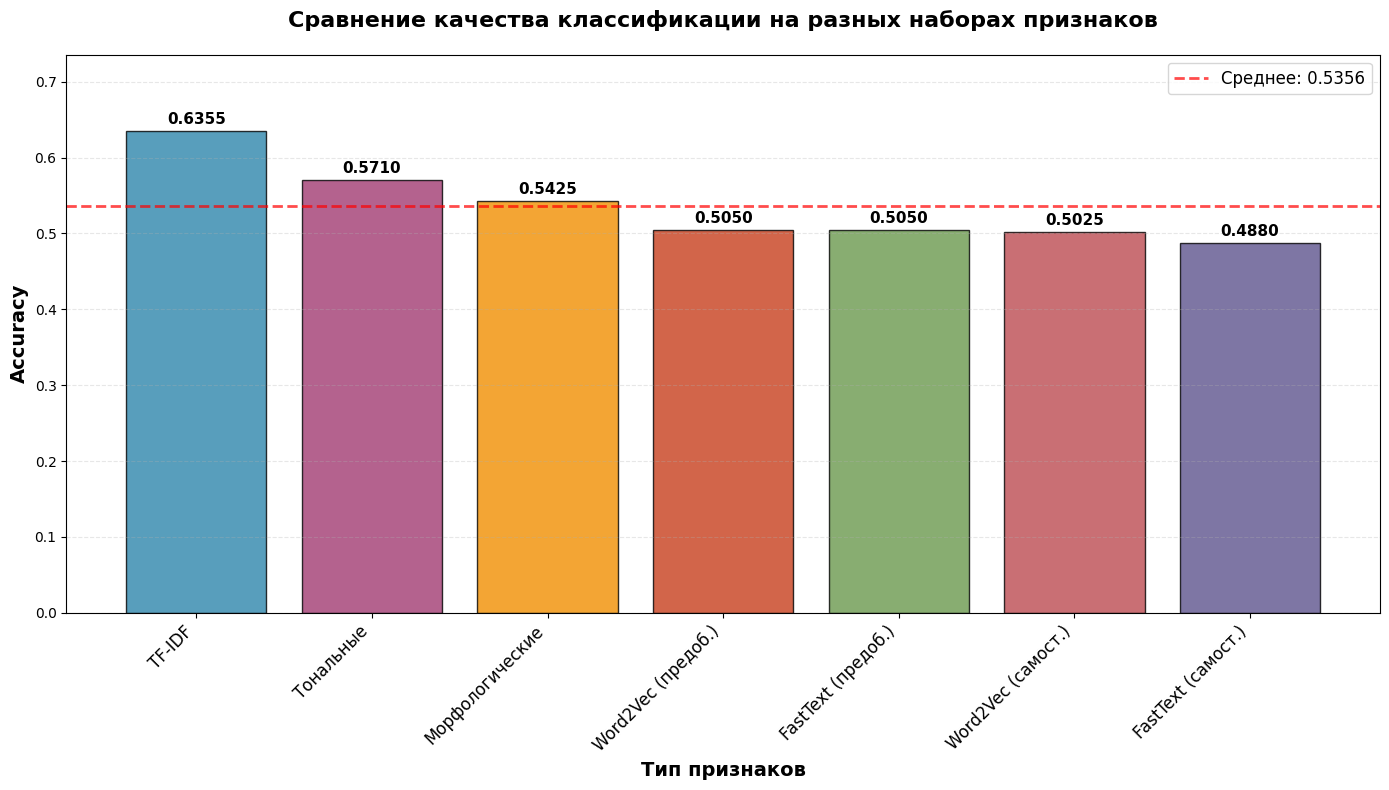

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


# Словарь со всеми наборами признаков
all_feature_sets = {
    # Ранние признаки
    'Тональные': ['avg', 'max', 'min', 'sum', 'pos', 'neg'],
    'Морфологические': [col for col in df.columns if col.startswith('pos_')],
    'TF-IDF': [col for col in df.columns if col.startswith('tfidf_')],

    # Векторные признаки
    'Word2Vec (самост.)': 'w2v_self',
    'Word2Vec (предоб.)': 'w2v_pre',
    'FastText (самост.)': 'ft_self',
    'FastText (предоб.)': 'ft_pre'
}

# Функция для получения accuracy
def get_accuracy(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))

# Собираем результаты
results = {}
y = df['label'].values

for name, features in all_feature_sets.items():
    print(f"  {name}", end=' ')

    if isinstance(features, list):  # Для тональных, морфо, tf-idf
        # Проверяем, что все колонки существуют
        existing_cols = [col for col in features if col in df.columns]
        if len(existing_cols) == 0:
            print(f" нет признаков")
            continue
        X = df[existing_cols].fillna(0).values
    else:  # Для векторных признаков
        if features not in df.columns:
            print(f" нет колонки {features}")
            continue
        X = np.vstack(df[features].values)

    acc = get_accuracy(X, y)
    results[name] = acc
    print(f" Accuracy: {acc:.4f}")

# Сортировка по убыванию accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
for name, acc in sorted_results.items():
    print(f"{name:25}: {acc:.4f}")

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(14, 8))

names = list(sorted_results.keys())
accuracies = list(sorted_results.values())

# Цвета для графиков
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#5E548E']

# Создание столбчатой диаграммы
bars = plt.bar(range(len(names)), accuracies, color=colors[:len(names)],
               alpha=0.8, edgecolor='black', linewidth=1)

# Добавление значений на столбцы
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Настройки графика
plt.xlabel('Тип признаков', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Сравнение качества классификации на разных наборах признаков',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(range(len(names)), names, rotation=45, ha='right', fontsize=12)
plt.ylim(0, max(accuracies) + 0.1)

# Добавление горизонтальной линии среднего значения
mean_acc = np.mean(accuracies)
plt.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Среднее: {mean_acc:.4f}')

plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()